# Odległość od Central Business District
Zakładając najprostszy możliwy sposób liczenia, czyli trochę arbitralnie wybrany konkretny punkt i odległość do niego w linii prostej

### Dodanie zmiennej określającej odległość

In [1]:
# Gemini mi poradził, żeby też tutaj zainstalować Pandas, bo wcześniej nie działało

%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Wczytanie danych
import pandas as pd
import numpy as np
data = pd.read_csv(r"dane/warszawa_lokale.csv")
data['creation_date'] = pd.to_datetime(data['creation_date'])

In [4]:
#Tutaj jest główny kod do obliczania odległości od CBD (Central Business District) w Warszawie, który wykorzystuje funkcję Haversine'a do obliczenia odległości między dwoma punktami geograficznymi na powierzchni Ziemi.

# 1. Definicja zwektoryzowanej funkcji
def odleglosc_punktow(p1, p2):
    # p1 i p2 to tablice/listy typu [szerokosc, dlugosc]
    p1 = np.array(p1)
    p2 = np.array(p2)

    K = 111_320  # Stała przelicznikowa dla stopni na metry (średnia wartość)
    
    # 1. Zwykła różnica współrzędnych pomnożona przez stałą K
    roznica = (p1 - p2) * K
    
    # 2. Korekta dla długości geograficznej (indeks 1 to długość)
    # Używamy średniej szerokości geograficznej obu punktów lub punktu startowego
    roznica[1] *= np.cos(np.radians(p1[0])) 
    
    # 3. Twierdzenie Pitagorasa: pierwiastek z sumy kwadratów różnic
    odleglosc = np.sqrt((roznica ** 2).sum(axis=0))
    
    return odleglosc



# 2. Zdefiniowanie punktu CBD

rondo_onz = np.array([52.2331227, 20.9983505])
rondo_daszynskiego = np.array([52.2303181, 20.9844480])
rondo_dmowskiego = np.array([52.2298297, 21.0117312])
pkin = np.array([52.2256658, 21.0038333])
dworzec_centralny = np.array([52.22882, 21.00287])

cbd = rondo_onz  # Możesz zmienić na inny punkt, np. rondo_daszynskiego, rondo_dmowskiego, pkin, dworzec_centralny



# 3. Obliczenie odległości i przypisanie do nowej kolumny
lokalizacja = np.array([data['latitude'], data['longitude']])
# Dopasowanie wymiarów punktu CBD do tablicy wielu lokalizacji
data['distance_to_cbd_m'] = odleglosc_punktow(
    lokalizacja,
    cbd[:, np.newaxis]
)

data[['name', 'latitude', 'longitude', 'distance_to_cbd_m']]

,name,latitude,longitude,distance_to_cbd_m
0,Ulica Ppłk. Macieja Kalenkiewicza „kotwicza” 10,52.229676,21.012229,1021.106742
1,Ulica Adolfa Pawińskiego 14,52.206051,20.977032,3346.154268
2,Ulica Adolfa Pawińskiego 14,52.206051,20.977032,3346.154268
3,Ulica Adolfa Pawińskiego 14,52.206051,20.977032,3346.154268
4,Ulica Adolfa Pawińskiego 14,52.206051,20.977032,3346.154268
...,...,...,...,...
229722,Ulica Oskara Kolberga 2,52.189839,21.011966,4907.141662
229723,Ulica Franciszka Raszei 6,52.245383,20.952285,3423.602260
229724,Ulica Bolesława Podczaszyńskiego 27,52.280252,20.956985,5954.947846
229725,Ulica Genewska 36,52.228358,21.055175,3910.702447


### Podstawowe sprawdzenie, czy zwracane wyniki mają sens.
Wstępnie, patrząc na mapę, to wygląda sensownie.

In [5]:
# Znalezienie rekordu z NAJMNIEJSZĄ odległością (najbliżej CBD)
najblizsza_nieruchomosc = data.loc[data['distance_to_cbd_m'].idxmin()]

# Znalezienie rekordu z NAJWIĘKSZĄ odległością (najdalej od CBD)
najdalsza_nieruchomosc = data.loc[data['distance_to_cbd_m'].idxmax()]

# Wyświetlenie wyników
print("=== Nieruchomość NAJBLIŻEJ centrum ===")
print(najblizsza_nieruchomosc[['name', 'latitude', 'longitude', 'distance_to_cbd_m']])
print("\n" + "="*38 + "\n") # Oddzielenie wyników
print("=== Nieruchomość NAJDALEJ od centrum ===")
print(najdalsza_nieruchomosc[['name', 'latitude', 'longitude', 'distance_to_cbd_m']])

=== Nieruchomość NAJBLIŻEJ centrum ===
name                 Aleja Jana Pawła II 18
latitude                          52.233813
longitude                         20.998791
distance_to_cbd_m                 82.523695
Name: 211618, dtype: object


=== Nieruchomość NAJDALEJ od centrum ===
name                 Ulica Podkowy 120P/1
latitude                        52.170439
longitude                       21.247732
distance_to_cbd_m             18400.73205
Name: 215865, dtype: object


In [6]:
print(data['distance_to_cbd_m'].describe())

count    229727.000000
mean       6540.033309
std        3270.009102
min          82.523695
25%        4164.083865
50%        6257.184356
75%        8593.285119
max       18400.732050
Name: distance_to_cbd_m, dtype: float64


### Wykres

In [7]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


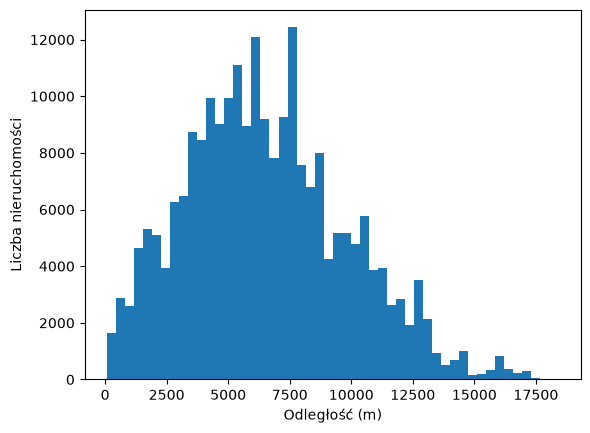

In [8]:
# Wykres histogramu odległości do CBD
import matplotlib.pyplot as plt

data['distance_to_cbd_m'].plot(kind='hist', bins=50)

plt.xlabel('Odległość (m)')
plt.ylabel('Liczba nieruchomości')
plt.show()

Zastanawiam się, czy przez to, że wykres jest taki "poszarpany" nie będzie problemu z overfittingiem, jeśli na podstawie odległości rozpozna konkretne okolice, w których sprzedano dużo mieszkań.

### Nieruchomości bardzo daleko i bardzo blisko

In [9]:
data[(data['distance_to_cbd_m'] > 17_500)]

,name,latitude,longitude,city,street,name.1,floor,rooms,size,amount,buyerType,sellerType,transactionType,marketType,participation,creation_date,classification,distance_to_cbd_m
215865,Ulica Podkowy 120P/1,52.170439,21.247732,Warszawa,Ulica Podkowy 120P/1,146514_8.1513.78_BUD.2_LOK,1.0,3,114.47,1209000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,pierwotny,1/1,2024-09-03,transakcja,18400.732050
215866,Ulica Podkowy 120P/1,52.170439,21.247732,Warszawa,Ulica Podkowy 120P/1,146514_8.1513.86/26.1_BUD.1_LOK,1.0,4,143.79,1359000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,pierwotny,1/1,2024-04-23,transakcja,18400.732050
228181,Ulica Świergotka 17,52.178537,21.244227,Warszawa,Ulica Świergotka 17,146514_8.1511.102_BUD.1_LOK,1.0,4,82.82,970000.0,osobaFizyczna,osobaPrawna,wolnyRynek,pierwotny,1/1,2025-07-10,transakcja,17850.052260
229201,Ulica Podkowy 126D,52.172449,21.246826,Warszawa,Ulica Podkowy 126D,146514_8.1513.101_BUD.2_LOK,1.0,6,100.28,1100000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2025-08-07,transakcja,18258.850724
229617,Ulica Świergotka 19,52.178657,21.243947,Warszawa,Ulica Świergotka 19,146514_8.1511.101_BUD.2_LOK,1.0,4,82.83,940000.0,osobaFizyczna,osobaPrawna,wolnyRynek,pierwotny,1/1,2025-11-13,transakcja,17827.517486
229659,Ulica Świergotka 23,52.178906,21.243363,Warszawa,Ulica Świergotka 23,146514_8.1511.99_BUD.2_LOK,1.0,4,82.83,995000.0,osobaFizyczna,osobaPrawna,wolnyRynek,pierwotny,1/1,2025-05-19,transakcja,17780.492313


In [10]:
data[(data['distance_to_cbd_m'] < 200)]

,name,latitude,longitude,city,street,name.1,floor,rooms,size,amount,buyerType,sellerType,transactionType,marketType,participation,creation_date,classification,distance_to_cbd_m
31779,Ulica Pańska 55,52.232037,20.996887,Warszawa,Ulica Pańska 55,146518_8.0108.5_BUD.15_LOK,5.0,2,24.59,565000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2025-07-28,transakcja,156.743071
31780,Ulica Pańska 55,52.232037,20.996887,Warszawa,Ulica Pańska 55,146518_8.0108.22.1_BUD.24_LOK,8.0,2,24.73,490000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2023-11-23,transakcja,156.743071
31781,Ulica Pańska 55,52.232037,20.996887,Warszawa,Ulica Pańska 55,146518_8.0108.22.1_BUD.48_LOK,5.0,2,24.97,407000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2023-05-29,transakcja,156.743071
31782,Ulica Pańska 55,52.232037,20.996887,Warszawa,Ulica Pańska 55,146518_8.0108.22.1_BUD.48_LOK,5.0,2,24.97,500000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2023-08-26,transakcja,156.743071
31783,Ulica Pańska 55,52.232037,20.996887,Warszawa,Ulica Pańska 55,146518_8.0108.22.1_BUD.54_LOK,7.0,2,25.72,285000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2018-03-08,transakcja,156.743071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218562,Aleja Jana Pawła II 20,52.234649,20.998491,Warszawa,Aleja Jana Pawła II 20,146510_8.0306.33_BUD.1401_LOK,15.0,3,39.55,655000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2024-08-22,transakcja,170.187201
218563,Aleja Jana Pawła II 20,52.234649,20.998491,Warszawa,Aleja Jana Pawła II 20,146510_8.0306.33_BUD.312_LOK,4.0,3,39.55,620000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2024-12-05,transakcja,170.187201
218564,Aleja Jana Pawła II 20,52.234649,20.998491,Warszawa,Aleja Jana Pawła II 20,146510_8.0306.33_BUD.725_LOK,8.0,3,39.55,400000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,2/3,2025-04-12,udzial,170.187201
218565,Aleja Jana Pawła II 20,52.234649,20.998491,Warszawa,Aleja Jana Pawła II 20,146510_8.0306.33_BUD.416_LOK,5.0,3,39.55,658000.0,osobaFizyczna,osobaFizyczna,wolnyRynek,wtorny,1/1,2025-07-17,transakcja,170.187201
